# Predicting Earnings Manipulation by Indian Firms

### Applied Business Analytics Group Assignment

This notebook answers the five assignment questions using a simple and explainable workflow.
The goal is not to build the most complicated model. The goal is to help MCA Technologies flag firms that may need further review.

**Data:** 220 firms with 8 Beneish-style financial indices and a binary target.

**Target:** `C-MANIPULATOR`, where 1 means manipulator and 0 means non-manipulator.

**Main model:** plain logistic regression using all 8 variables. No L2 regularisation is used in the main logistic model.

In [1]:
import os
os.environ['MPLCONFIGDIR'] = '/private/tmp/matplotlib-cache'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

## Load the data

In [2]:
DATA_PATH = 'Case Data NS.csv'
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

X_COLS = ['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'ACCR', 'LEVI']
TARGET = 'C-MANIPULATOR'

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Target distribution:')
print(df[TARGET].value_counts())
df.head()

Shape: (220, 11)
Columns: ['Company ID', 'DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'ACCR', 'LEVI', 'Manipulator', 'C-MANIPULATOR']
Target distribution:
C-MANIPULATOR
0    181
1     39
Name: count, dtype: int64


,Company ID,DSRI,GMI,AQI,SGI,DEPI,SGAI,ACCR,LEVI,Manipulator,C-MANIPULATOR
0,1,1.624742,1.128927,7.185053,0.366211,1.381519,1.624145,-0.166809,1.161082,Yes,1
1,2,1.000000,1.606492,1.004988,13.081433,0.400000,5.198207,0.060475,0.986732,Yes,1
2,3,1.000000,1.015607,1.241389,1.475018,1.169353,0.647671,0.036732,1.264305,Yes,1
3,4,1.486239,1.000000,0.465535,0.672840,2.000000,0.092890,0.273434,0.680975,Yes,1
4,5,1.000000,1.369038,0.637112,0.861346,1.454676,1.741460,0.123048,0.939047,Yes,1


# Q1. Class imbalance problem and handling

The dataset is imbalanced because manipulators are much fewer than non-manipulators. This creates four practical problems:

1. **Accuracy can be misleading.** A model can get high accuracy by predicting almost every firm as non-manipulator.
2. **The minority class can be missed.** In this assignment, missing a manipulator is more serious than flagging a clean firm for review.
3. **The model threshold matters.** The default probability cut-off of 0.50 may be too strict for a screening model.
4. **Evaluation needs more than accuracy.** We should also check sensitivity, specificity, ROC-AUC, PR-AUC, and the confusion matrix.

In this notebook, class imbalance is handled in a simple way:

- Use a stratified train-test split so both sets have similar manipulator proportions.
- Report sensitivity and false negatives, not only accuracy.
- Use a lower screening threshold for the logistic model when the business objective is to catch more manipulators.
- Use `class_weight='balanced'` in tree models where appropriate.

In [3]:
positive_rate = df[TARGET].mean()
naive_accuracy = 1 - positive_rate

print(f'Manipulators: {df[TARGET].sum()} out of {len(df)} ({positive_rate:.1%})')
print(f'Accuracy if we predict every firm as non-manipulator: {naive_accuracy:.1%}')
print('But that model would catch 0 manipulators, so accuracy alone is not enough.')

Manipulators: 39 out of 220 (17.7%)
Accuracy if we predict every firm as non-manipulator: 82.3%
But that model would catch 0 manipulators, so accuracy alone is not enough.


# Q2. Logistic regression model

The logistic regression model predicts the probability that a firm is a manipulator. All 8 available financial indices are used so the model remains directly connected to the case variables.

## Exploratory analysis

In [4]:
summary = df.groupby(TARGET)[X_COLS].mean().T
summary.columns = ['Non-manipulator mean', 'Manipulator mean']
summary['Difference'] = summary['Manipulator mean'] - summary['Non-manipulator mean']
summary.round(4)

,Non-manipulator mean,Manipulator mean,Difference
DSRI,1.1603,3.2080,2.0477
GMI,0.8751,2.1606,1.2855
AQI,1.0188,2.9087,1.8899
SGI,1.0818,1.8496,0.7678
DEPI,1.0438,0.9664,-0.0774
SGAI,1.1201,2.7746,1.6545
ACCR,-0.0322,0.0541,0.0863
LEVI,1.0339,1.4554,0.4215


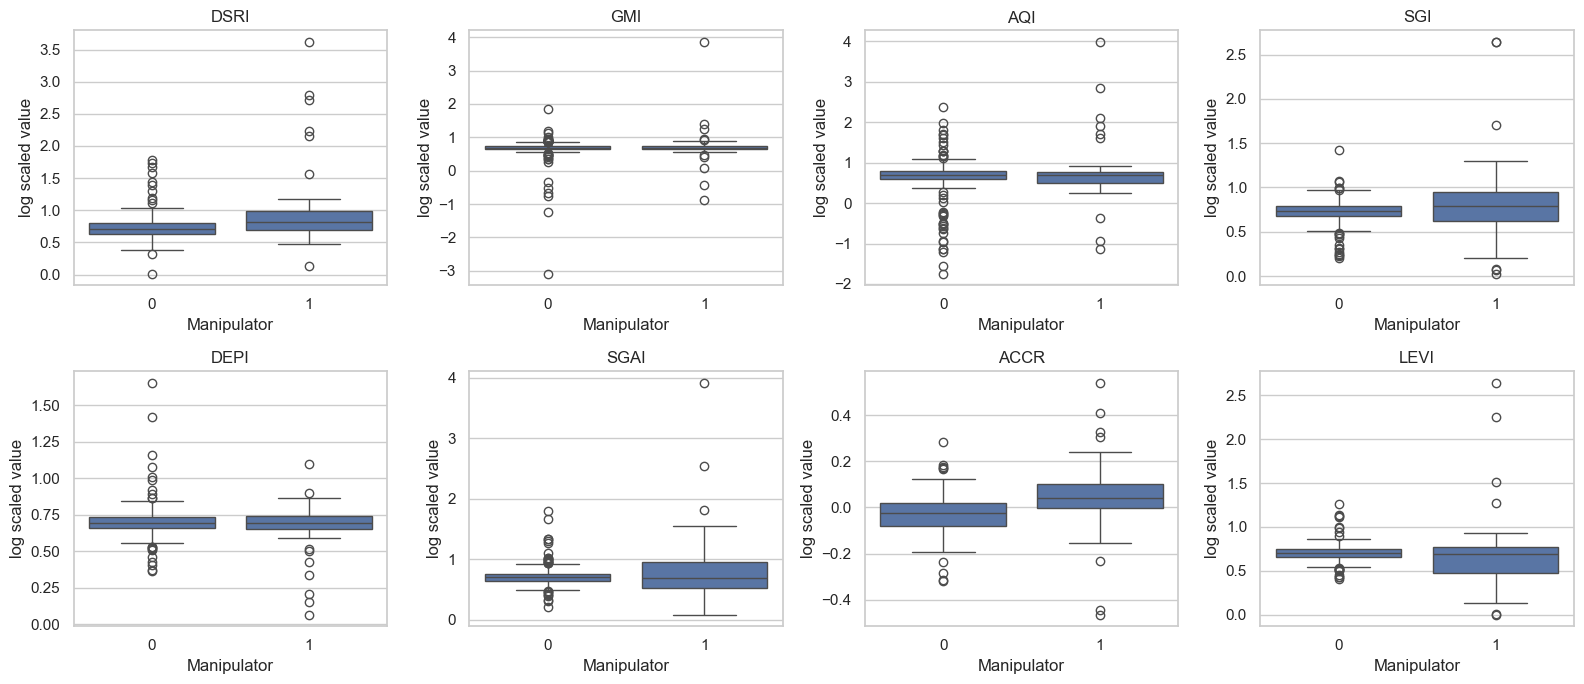

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), X_COLS):
    plot_df = df[[col, TARGET]].copy()
    plot_df[col] = np.sign(plot_df[col]) * np.log1p(np.abs(plot_df[col]))
    sns.boxplot(data=plot_df, x=TARGET, y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Manipulator')
    ax.set_ylabel('log scaled value')
plt.tight_layout()
plt.show()

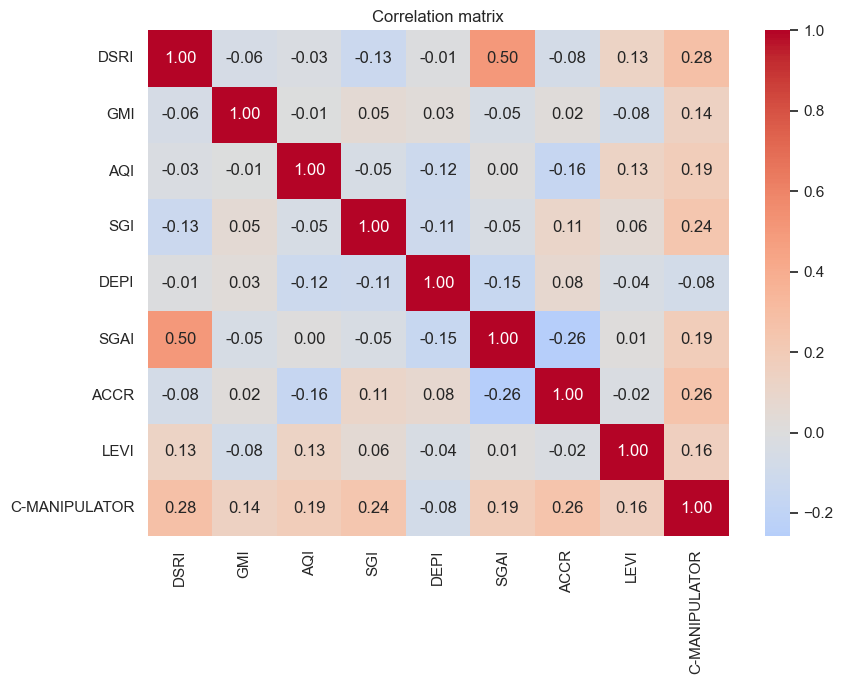

In [6]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[X_COLS + [TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

## Train-test split

A 70:30 stratified split is used. Stratification keeps the manipulator share similar in train and test data.

In [7]:
X = df[X_COLS].astype(float)
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print('Train shape:', X_train.shape, '| manipulators:', int(y_train.sum()), f'({y_train.mean():.1%})')
print('Test shape :', X_test.shape,  '| manipulators:', int(y_test.sum()),  f'({y_test.mean():.1%})')

Train shape: (154, 8) | manipulators: 27 (17.5%)
Test shape : (66, 8) | manipulators: 12 (18.2%)


In [8]:
def make_plain_logistic():
    """Create an unregularised logistic regression model across sklearn versions."""
    try:
        return LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000)
    except Exception:
        return LogisticRegression(penalty='none', solver='lbfgs', max_iter=10000)

logit_model = make_plain_logistic()
logit_model.fit(X_train, y_train)

coef_table = pd.DataFrame({
    'Variable': X_COLS,
    'Coefficient': logit_model.coef_[0],
    'Odds ratio': np.exp(logit_model.coef_[0])
}).sort_values('Coefficient', ascending=False)

print('Intercept:', round(logit_model.intercept_[0], 4))
coef_table.round(4)

Intercept: -8.9072


,Variable,Coefficient,Odds ratio
6,ACCR,8.4587,4715.8984
3,SGI,2.4438,11.5170
1,GMI,1.2795,3.5950
0,DSRI,1.2062,3.3407
2,AQI,0.7061,2.0261
4,DEPI,0.2290,1.2573
5,SGAI,-0.0268,0.9735
7,LEVI,-0.1929,0.8245


### Logistic model interpretation

Positive coefficients increase the predicted probability of manipulation. Negative coefficients reduce it. The strongest positive signals in this fit are accruals, sales growth, receivables growth, gross margin deterioration, and asset quality.

The odds ratios are useful for direction, but they should not be compared blindly across variables because the variables have different scales.

In [9]:
formula_parts = [f'({logit_model.coef_[0][i]:.4f} x {col})' for i, col in enumerate(X_COLS)]
print('Logit probability =', f'{logit_model.intercept_[0]:.4f}', '+', ' + '.join(formula_parts))
print('Probability = 1 / (1 + exp(-logit probability))')

Logit probability = -8.9072 + (1.2062 x DSRI) + (1.2795 x GMI) + (0.7061 x AQI) + (2.4438 x SGI) + (0.2290 x DEPI) + (-0.0268 x SGAI) + (8.4587 x ACCR) + (-0.1929 x LEVI)
Probability = 1 / (1 + exp(-logit probability))


# Q3. Model goodness, accuracy and insights

For a fraud or manipulation screening problem, the confusion matrix is more useful than accuracy alone. The model should avoid missing too many manipulators, even if that means sending more firms for review.

In [10]:
def metric_row(name, actual, prob, threshold):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual, pred, labels=[0, 1]).ravel()
    return {
        'Model / threshold': name,
        'Accuracy': accuracy_score(actual, pred),
        'Sensitivity': recall_score(actual, pred),
        'Specificity': tn / (tn + fp),
        'Precision': precision_score(actual, pred, zero_division=0),
        'F1': f1_score(actual, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(actual, prob),
        'PR-AUC': average_precision_score(actual, prob),
        'False positives': fp,
        'False negatives': fn
    }

def draw_confusion(actual, prob, threshold, title):
    pred = (prob >= threshold).astype(int)
    cm = confusion_matrix(actual, pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-manipulator', 'Manipulator'],
                yticklabels=['Non-manipulator', 'Manipulator'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.show()

train_prob = logit_model.predict_proba(X_train)[:, 1]
test_prob = logit_model.predict_proba(X_test)[:, 1]

# Simple screening policy: use a lower cut-off than 0.50 because the goal is
# to catch possible manipulators and send them for review.
best_threshold = 0.10
print(f'Screening threshold used for MCA review list: {best_threshold:.2f}')
print('Reason: this is a screening model, so missing a manipulator is worse than reviewing extra firms.')

Screening threshold used for MCA review list: 0.10
Reason: this is a screening model, so missing a manipulator is worse than reviewing extra firms.


In [11]:
results_logit = pd.DataFrame([
    metric_row('Logistic at 0.50 default', y_test, test_prob, 0.50),
    metric_row(f'Logistic at {best_threshold:.2f} screening', y_test, test_prob, best_threshold)
])
results_logit.round(4)

,Model / threshold,Accuracy,Sensitivity,Specificity,Precision,F1,ROC-AUC,PR-AUC,False positives,False negatives
0,Logistic at 0.50 default,0.8636,0.3333,0.9815,0.8000,0.4706,0.9244,0.7303,1,8
1,Logistic at 0.10 screening,0.8333,0.8333,0.8333,0.5263,0.6452,0.9244,0.7303,9,2


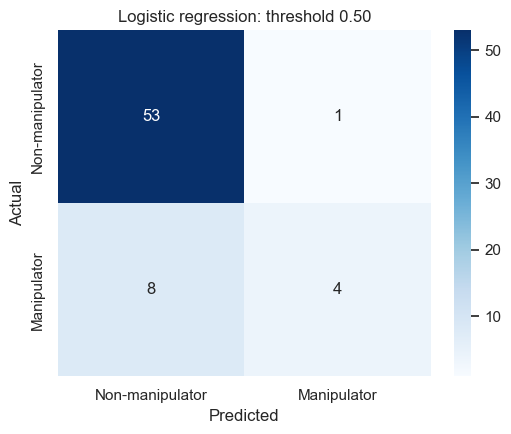

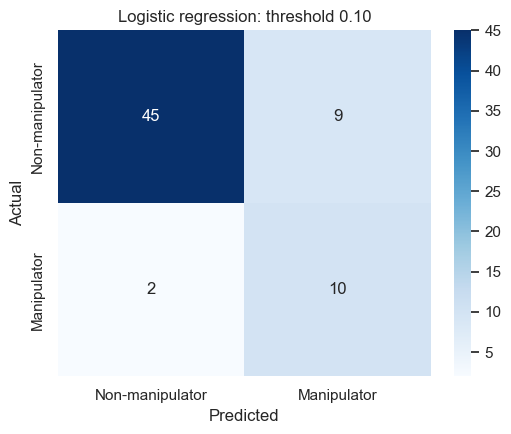

In [12]:
plt.figure(figsize=(5.5, 4.5))
draw_confusion(y_test, test_prob, 0.50, 'Logistic regression: threshold 0.50')

plt.figure(figsize=(5.5, 4.5))
draw_confusion(y_test, test_prob, best_threshold, f'Logistic regression: threshold {best_threshold:.2f}')

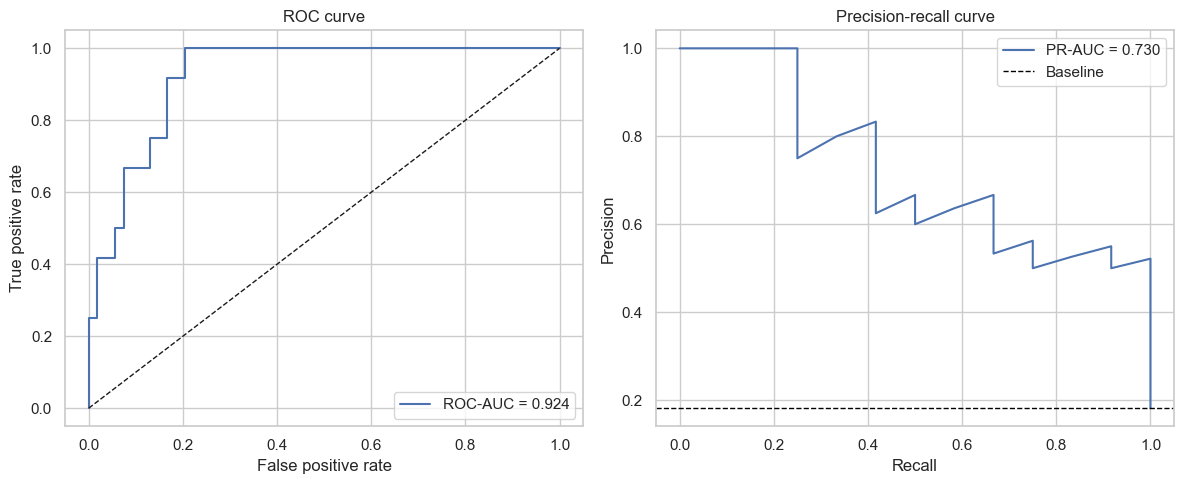

In [13]:
fpr, tpr, _ = roc_curve(y_test, test_prob)
precision, recall, _ = precision_recall_curve(y_test, test_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, test_prob):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(recall, precision, label=f'PR-AUC = {average_precision_score(y_test, test_prob):.3f}')
axes[1].axhline(y_test.mean(), color='black', linestyle='--', linewidth=1, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-recall curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## Diagnostic plots

For logistic regression, residuals are not expected to be normally distributed like linear regression residuals. The plots below are used mainly to check whether the model has obvious unusual cases or poor probability calibration.

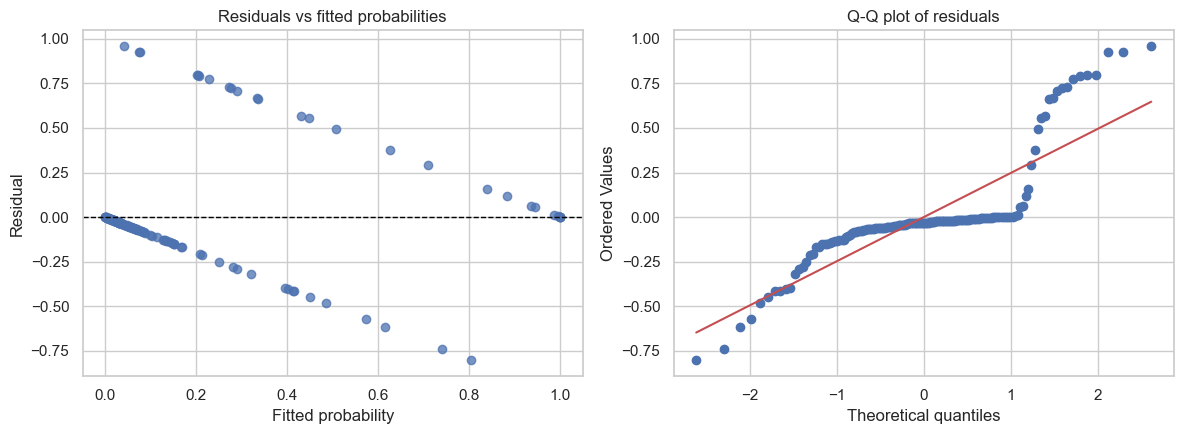

In [14]:
residuals = y_train - train_prob

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(train_prob, residuals, alpha=0.75)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted probability')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs fitted probabilities')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot of residuals')
plt.tight_layout()
plt.show()

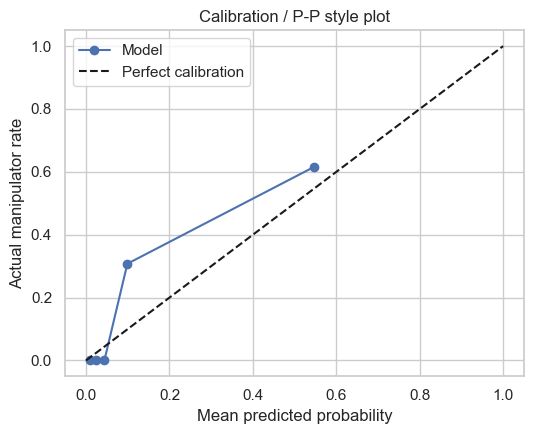

In [15]:
prob_true, prob_pred = calibration_curve(y_test, test_prob, n_bins=5, strategy='quantile')

plt.figure(figsize=(5.5, 4.5))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Actual manipulator rate')
plt.title('Calibration / P-P style plot')
plt.legend()
plt.tight_layout()
plt.show()

## Main insights from logistic regression

1. **Accruals are the clearest warning sign.** Higher accruals mean earnings are less supported by cash flows.
2. **Growth-related variables matter.** Sales growth and receivables growth both raise manipulation risk.
3. **The default 0.50 threshold is too strict for screening.** It gives high accuracy but misses many manipulators.
4. **A lower screening threshold is more suitable for MCA.** It catches more manipulators, while the false positives can be reviewed manually.

# Q4. Other machine learning models

The logistic regression model is compared with a decision tree, random forest, gradient boosting model, KNN, and the published Beneish M-score. The aim is to see whether a more flexible model gives better predictive performance.

In [16]:
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=3, class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'KNN': Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance'))])
}

comparison_rows = [metric_row(f'Logistic at {best_threshold:.2f}', y_test, test_prob, best_threshold)]
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    prob = model.predict_proba(X_test)[:, 1]
    comparison_rows.append(metric_row(name, y_test, prob, 0.50))

# Published Beneish M-score benchmark. Higher score means higher manipulation risk.
def beneish_m_score(d):
    return (-4.84 + 0.920*d['DSRI'] + 0.528*d['GMI'] + 0.404*d['AQI'] + 0.892*d['SGI']
            + 0.115*d['DEPI'] - 0.172*d['SGAI'] + 4.679*d['ACCR'] - 0.327*d['LEVI'])

m_test = beneish_m_score(X_test)
comparison_rows.append(metric_row('Beneish M-score', y_test, m_test, -1.78))

comparison = pd.DataFrame(comparison_rows).sort_values('ROC-AUC', ascending=False)
comparison.round(4)

,Model / threshold,Accuracy,Sensitivity,Specificity,Precision,F1,ROC-AUC,PR-AUC,False positives,False negatives
0,Logistic at 0.10,0.8333,0.8333,0.8333,0.5263,0.6452,0.9244,0.7303,9,2
5,Beneish M-score,0.8485,0.5833,0.9074,0.5833,0.5833,0.9090,0.6526,5,5
2,Random Forest,0.8333,0.3333,0.9444,0.5714,0.4211,0.8225,0.5213,3,8
4,KNN,0.8485,0.1667,1.0000,1.0000,0.2857,0.8071,0.6574,0,10
3,Gradient Boosting,0.7727,0.1667,0.9074,0.2857,0.2105,0.7847,0.4742,5,10
1,Decision Tree,0.7273,0.1667,0.8519,0.2000,0.1818,0.5100,0.1909,8,10


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

cv_models = {'Logistic': make_plain_logistic(), **models}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_rows.append({'Model': name, 'Mean CV ROC-AUC': scores.mean(), 'Std. dev.': scores.std()})

pd.DataFrame(cv_rows).sort_values('Mean CV ROC-AUC', ascending=False).round(4)

,Model,Mean CV ROC-AUC,Std. dev.
2,Random Forest,0.8648,0.0869
3,Gradient Boosting,0.8455,0.0995
0,Logistic,0.8129,0.0886
4,KNN,0.8054,0.0862
1,Decision Tree,0.6593,0.1053


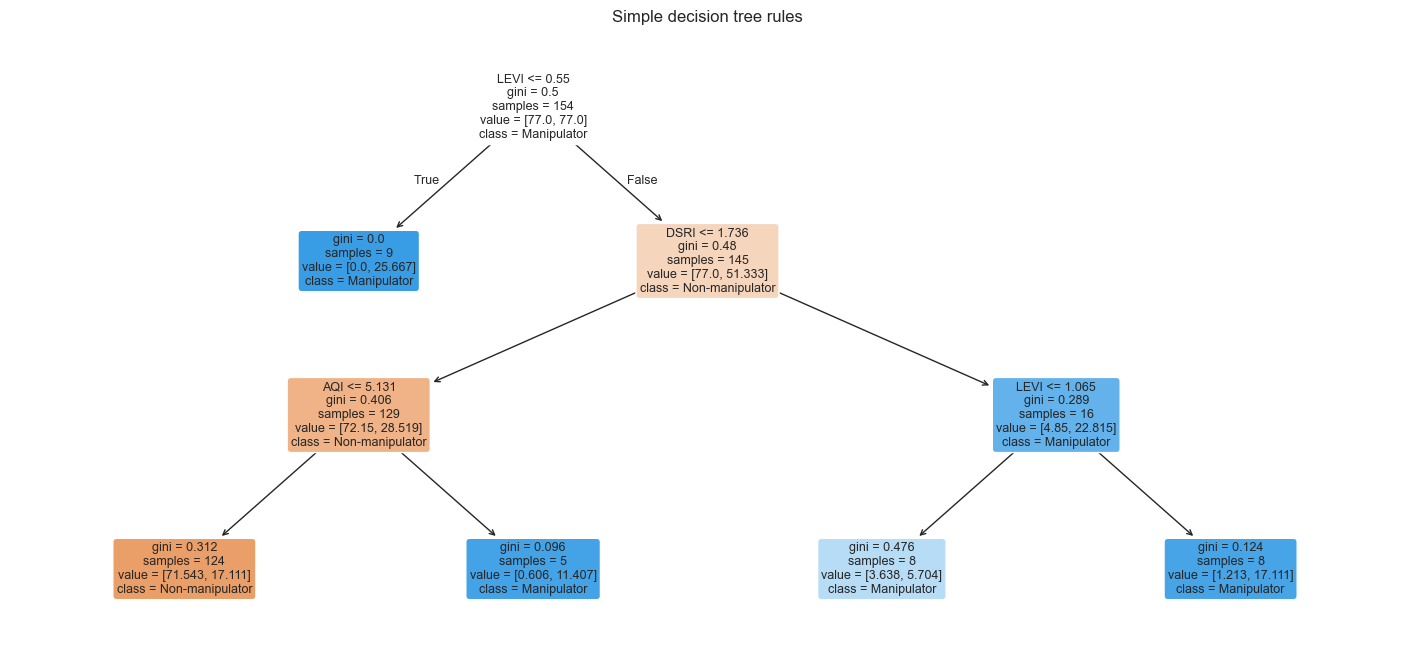

In [18]:
plt.figure(figsize=(18, 8))
plot_tree(
    fitted_models['Decision Tree'],
    feature_names=X_COLS,
    class_names=['Non-manipulator', 'Manipulator'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Simple decision tree rules')
plt.show()

## Interpretation of other models

The alternative models are useful checks, but logistic regression remains the best model for deployment because it is accurate, simple, and explainable. Random forest and gradient boosting can be harder to explain to auditors. KNN is also less suitable because it does not give simple business rules. The decision tree is useful as an explanation tool, but it is less stable as the main model.

# Q5. Deployment strategy for MCA Technologies

Recommended deployment strategy:

1. **Use logistic regression as the main screening model.** It gives strong ranking performance and clear coefficient interpretation.
2. **Use the lower screening threshold, not only 0.50.** A screening model should catch more possible manipulators and then send them for review.
3. **Create three risk bands.** High risk firms go to forensic review, medium risk firms go to desk review, and low risk firms are monitored normally.
4. **Use the decision tree as an explanation aid.** It can help analysts understand common rules behind risky cases.
5. **Re-train the model periodically.** Financial reporting patterns may change, so the model should be updated with newer labelled cases.
6. **Do not treat the model as proof of manipulation.** It is only a prioritisation tool for investigation.

In [19]:
risk_table = pd.DataFrame({
    'Company ID': df.loc[X_test.index, 'Company ID'].values,
    'Actual manipulator': y_test.values,
    'Predicted probability': test_prob
})

risk_table['Risk band'] = pd.cut(
    risk_table['Predicted probability'],
    bins=[-0.001, best_threshold, 0.50, 1.001],
    labels=['Low: monitor normally', 'Medium: desk review', 'High: forensic review']
)

print('Number of firms in each risk band:')
print(risk_table['Risk band'].value_counts().sort_index())

risk_table.sort_values('Predicted probability', ascending=False).head(15).round(4)

Number of firms in each risk band:
Risk band
Low: monitor normally    47
Medium: desk review      14
High: forensic review     5
Name: count, dtype: int64


,Company ID,Actual manipulator,Predicted probability,Risk band
33,2,1,1.0000,High: forensic review
4,24,1,1.0000,High: forensic review
42,35,1,0.9897,High: forensic review
65,41,0,0.9411,High: forensic review
12,12,1,0.5406,High: forensic review
19,37,1,0.4899,Medium: desk review
40,77,0,0.4823,Medium: desk review
58,171,0,0.4281,Medium: desk review
39,39,1,0.3570,Medium: desk review
59,112,0,0.3327,Medium: desk review


## Final conclusion

The plain logistic regression model is recommended for MCA Technologies. It performs well on the test data and is easier to explain than more complex machine learning models. Because earnings manipulation is a rare event, MCA should use the model as a screening system with a lower threshold, not as a final fraud verdict.